# MLM vs. $\chi^2$

Cíl je porovnat modifikovaný MLM fit se standardním fitem pomocí $\chi^2$. Máme data co mají "divočejší taily", a tak můžou mít i záporné obsahy binů.

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

#import matplotlib
#matplotlib.use('svg')
%matplotlib inline
%config InlineBackend.figure_format='svg'

def carl_friedrich(x,a,mu,sig):
    return a * np.exp(-(x - mu)**2/(2*sig**2))

## Generování dat
Reálná měření vždy obsahují šum. Simulujeme jako, normální rozdělení (signál), k němu přičteme uniformní šum a odečteme data z jiného uniformního rozdělení (simulované měření pozadí). 

Konečná data pro fitování jsou: `hist_data = h1 + h2 - h3`
* **h1:** Gaussovská data signálu.
* **h2:** Uniformní data pozadí.
* **h3:** Uniformní data pozadí.

Odečtení pozadí $h3$ umožňuje vznik binů i se záporným obsahem (záporné $N_k$). Standardní Poisson v MLM modeluje pravděpodobnost naměření $N_k$ událostí jako $$p(N_k|D_k) = \frac{D_k^{N_k} e^{-D_k}}{N_k!}.$$ Nepořádek dělá faktoriál ($N_k!$), který není pro záporná čísla definován. Proto modifikovaná MLM.

In [4]:
# params
np.random.seed(67) # for repoducibility
N_events = 10000
true_x0, true_sigma = 5.0, 1.0
x_min, x_max, n_bins = 0, 10, 50

# data
data_gauss = np.random.normal(true_x0, true_sigma, N_events)
data_flat_add = np.random.uniform(x_min, x_max, N_events)
data_flat_sub = np.random.uniform(x_min, x_max, N_events)

# data to histograms
h1, bin_edges = np.histogram(data_gauss, bins=n_bins, range=(x_min, x_max))
h2, _ = np.histogram(data_flat_add, bins=n_bins, range=(x_min, x_max))
h3, _ = np.histogram(data_flat_sub, bins=n_bins, range=(x_min, x_max))

# bin centres and contents
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
hist_data = h1 + h2 - h3

# simulated error for chi2 fit
bin_errors = np.sqrt(h1 + h2 + h3)
valid_bins = bin_errors > 0 

## Modifikovaný (ne)binovaný MLM fit

 Kvůli problému s Poisonem převedeme binovaný MLM na nebinovaný. Místo počítání statistiky $N_k$ měření v daném binu, budeme předstírat, že jsme provedli $N_k$ nezávislých měření, která všechna padla přesně na střed binu ($x_k$).

Hustota pravděpodobnosti, že jedno měření dopadne do bodu $x_k$, je: $$p(x_k | x_0, \sigma) = A \cdot \exp\left(-\frac{(x_k - x_0)^2}{2\sigma^2}\right),$$ kde $A = \frac{1}{\sqrt{2\pi}\sigma}$.

Pokud bereme $N_k$ událostí jako nezávislé měření co padly do $x_k$ tak celková pravděpodobnost pro tento bin ($N_k$ měření do něj padlo) je $N_k$-tá mocnina pravděpodobnosti jednoho měření: $$L = \left( A \cdot \exp\left(-\frac{(x_k - x_0)^2}{2\sigma^2}\right) \right)^{N_k}.$$

Vynásobením všech $M$ binů máme celkovou věrohodnost. Produkt a mocnina jsou pomalé, proto zlogaritmujeme:
   $$ \ln L = \sum_{k=1}^{M} N_k \left( \ln A - \frac{(x_k - x_0)^2}{2\sigma^2} \right).$$

In [5]:
def negative_log_likelihood(params):
    x0, sigma = params
    if sigma <= 0: return np.inf # Sigma must be positive
    
    A = 1.0 / (np.sqrt(2 * np.pi) * sigma)
    log_terms = np.log(A) - ((bin_centers - x0)**2) / (2 * sigma**2)
    
    log_likelihood = -np.sum(hist_data * log_terms)
    return log_likelihood

## $\chi^2$ fit

Metoda $\chi^2$ je specifickým případem MLM. Místo toho, že se biny plní podle Poissona, předpokládá, že obsah $k$-tého binu, $N_k$, je náhodná veličina z Gaussova rozdělení. Rozdělení je centrováno na očekávané hodnotě, $D_k$, se známou nejistotou, $\sigma_k$.

Likelihood pro všech $M$ binů je součinem jejich jednotlivých Gaussovských pravděpodobností:
   $$ L = \prod_{k=1}^{M} \frac{1}{\sqrt{2\pi}\sigma_k} \exp\left(-\frac{(N_k - D_k)^2}{2\sigma_k^2}\right) $$
Zlogaritmujeme....$\ln L = \text{konst.} - \frac{1}{2} \sum_{k=1}^{M} \left( \frac{N_k - D_k}{\sigma_k} \right)^2$ 

Člen se sumou je označíme jako $\chi^2$. Protože $\ln L = \text{konst.} - \frac{1}{2} \chi^2$, maximalizace pravděpodobnosti vyžaduje minimalizaci $\chi^2$.

$$ \chi^2 = \sum_{k=1}^{M} \left(\frac{N_k - D_k}{\sigma_k}\right)^2 $$

In [8]:
def chi_square(params):
    Amplitude, x0, sigma = params
    if sigma <= 0: return np.inf
    
    # Expected value of bin based on the Gaussian model
    D_k = Amplitude * np.exp(-((bin_centers - x0)**2) / (2 * sigma**2))
    
    # chi2 only valid bins to avoid division by zero
    chi2_val = np.sum(((hist_data[valid_bins] - D_k[valid_bins]) / bin_errors[valid_bins])**2)
    return chi2_val

## 4. Spuštění a vizualizace
Nyní spustíme optimalizaci pro obě metody. Protože modifikovaná MLM fituje pouze parametry tvaru ($x_0$, $\sigma$) a zachází s obsahy $N_k$ jako s prostorovými četnostmi, nevrací absolutní vertikální amplitudu. Pro vizuální porovnání v grafu škálujeme křivku MLM amplitudou nalezenou pomocí $\chi^2$ fitu.

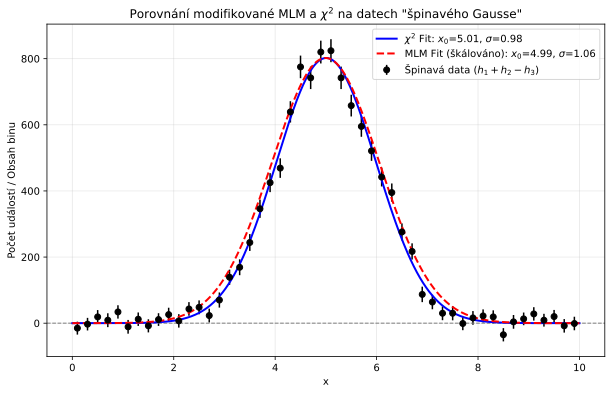

Skutečné hodnoty: x0 = 5.0, sigma = 1.0
MLM Fit         : x0 = 4.995, sigma = 1.059
Chi2 Fit        : x0 = 5.006, sigma = 0.984


In [12]:
%matplotlib inline

# Počáteční odhady a optimalizace
guess_MLM = [4.5, 1.5]
guess_Chi2 = [np.max(hist_data), 4.5, 1.5]

result_MLM = minimize(negative_log_likelihood, guess_MLM, method='Nelder-Mead')
result_Chi2 = minimize(chi_square, guess_Chi2, method='Nelder-Mead')

fit_x0_mlm, fit_sigma_mlm = result_MLM.x
fit_A_chi2, fit_x0_chi2, fit_sigma_chi2 = result_Chi2.x

# Vizualizace
plt.figure(figsize=(10, 6))
plt.errorbar(bin_centers, hist_data, yerr=bin_errors, fmt='o', color='black', label='Špinavá data ($h_1 + h_2 - h_3$)')
plt.axhline(0, color='gray', linestyle='--', linewidth=1)

x_plot = np.linspace(x_min, x_max, 500)

# Křivka Chi2
chi2_curve = fit_A_chi2 * np.exp(-((x_plot - fit_x0_chi2)**2) / (2 * fit_sigma_chi2**2))
plt.plot(x_plot, chi2_curve, color='blue', linewidth=2, 
         label=f'$\chi^2$ Fit: $x_0$={fit_x0_chi2:.2f}, $\sigma$={fit_sigma_chi2:.2f}')

# Škálovaná křivka MLM
mlm_curve = fit_A_chi2 * np.exp(-((x_plot - fit_x0_mlm)**2) / (2 * fit_sigma_mlm**2))
plt.plot(x_plot, mlm_curve, color='red', linestyle='--', linewidth=2, 
         label=f'MLM Fit (škálováno): $x_0$={fit_x0_mlm:.2f}, $\sigma$={fit_sigma_mlm:.2f}')

plt.title('Porovnání modifikované MLM a $\chi^2$ na datech "špinavého Gausse"')
plt.xlabel('x')
plt.ylabel('Počet událostí / Obsah binu')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Vypsání porovnání
print(f"Skutečné hodnoty: x0 = {true_x0}, sigma = {true_sigma}")
print(f"MLM Fit         : x0 = {fit_x0_mlm:.3f}, sigma = {fit_sigma_mlm:.3f}")
print(f"Chi2 Fit        : x0 = {fit_x0_chi2:.3f}, sigma = {fit_sigma_chi2:.3f}")